=== 5 Data Teratas (Data Asli) ===
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1   

=== Unique value pada kolom 'Personal Loan' (Data Asli) 

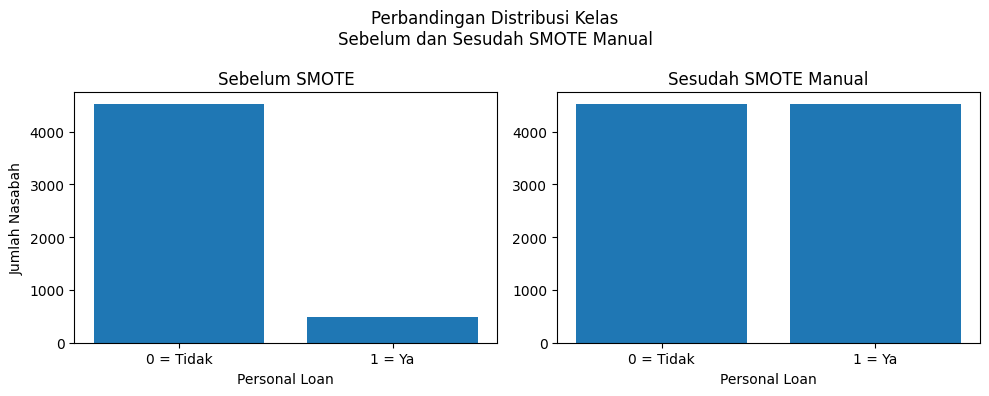

Explained variance ratio (SEBELUM SMOTE, PC1–PC3):
[0.18622775 0.16876493 0.12857527]
Cumulative: [0.18622775 0.35499268 0.48356795] 



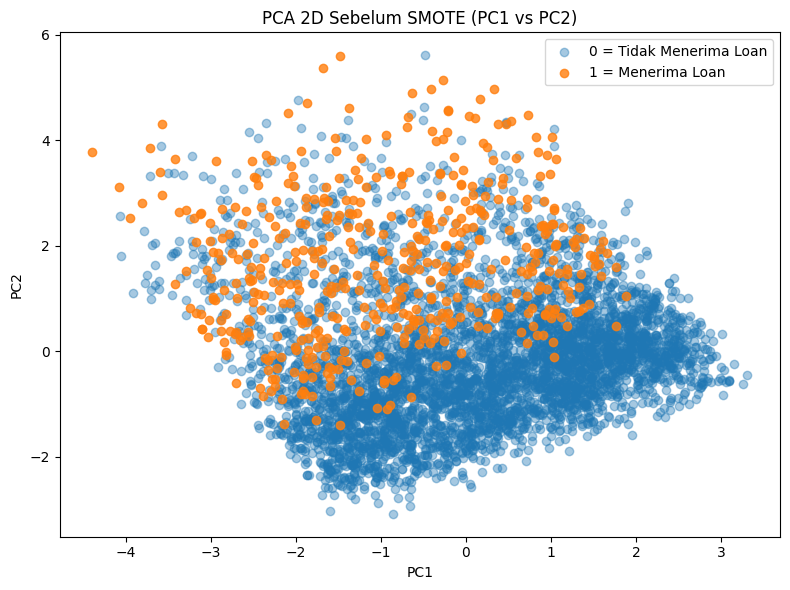

Explained variance ratio (SETELAH SMOTE, PC1–PC3):
[0.18753741 0.18202217 0.11934513]
Cumulative: [0.18753741 0.36955958 0.48890471] 



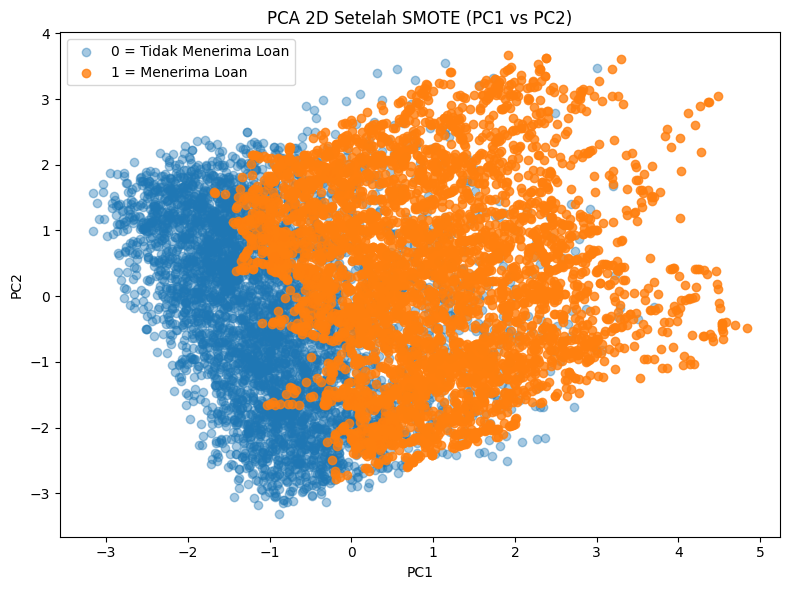

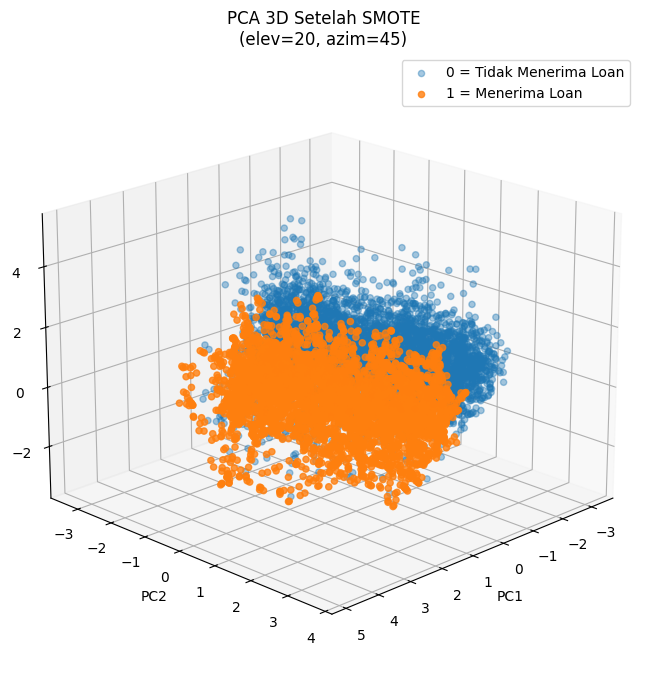

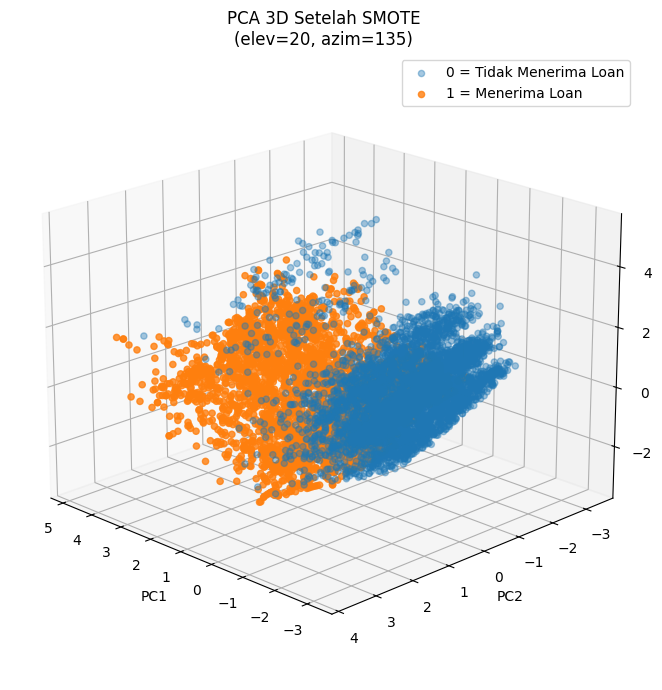

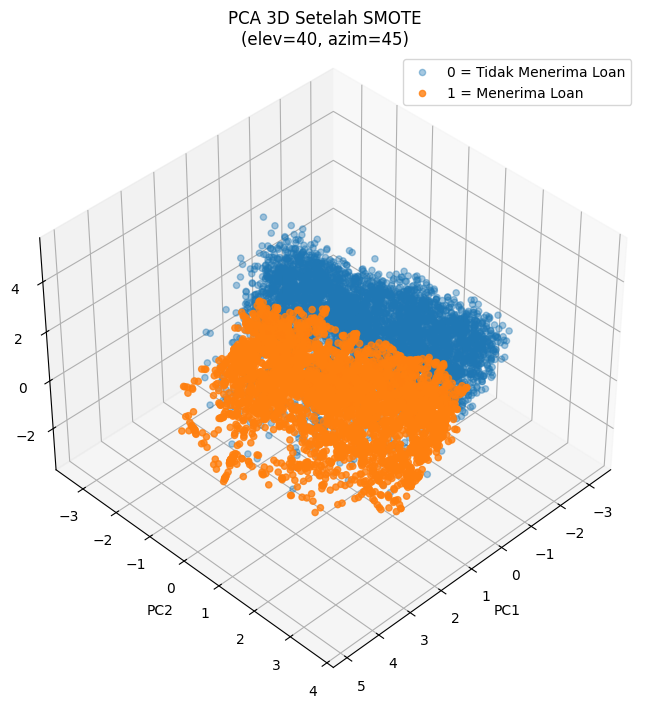

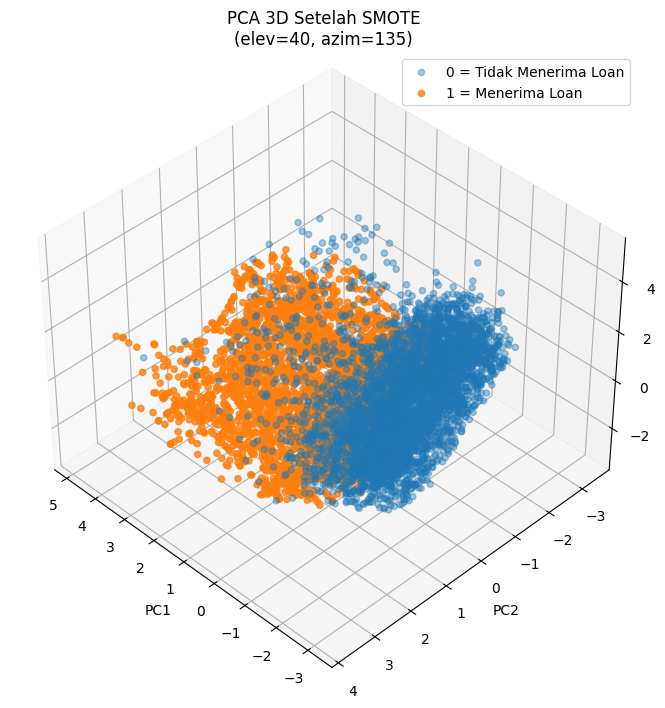

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors  # hanya KNN, bukan SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # untuk plot 3D

# =========================
# 1. Load dataset
# =========================
df = pd.read_csv("dataset/bank_personal_loan_data.csv")

print("=== 5 Data Teratas (Data Asli) ===")
print(df.head(), "\n")

# =========================
# 2. Analisis target (data asli)
# =========================
print("=== Unique value pada kolom 'Personal Loan' (Data Asli) ===")
print(df["Personal Loan"].value_counts(), "\n")

class_counts_before = df["Personal Loan"].value_counts().sort_index()
class_percent_before = df["Personal Loan"].value_counts(normalize=True).sort_index() * 100

dist_before = pd.DataFrame({
    "Kelas": ["0 = Tidak Menerima Loan", "1 = Menerima Loan"],
    "Jumlah": class_counts_before.values,
    "Persentase (%)": class_percent_before.round(2).values
})

print("=== Distribusi Kelas Personal Loan (Data Asli) ===")
print(dist_before, "\n")

# =========================
# 3. Statistik deskriptif (tanpa ID & ZIP Code) - Data Asli
# =========================
drop_cols = ["ID", "ZIP Code"]

numeric_all = df.select_dtypes(include=["int64", "float64"]).columns
numeric_for_desc = [c for c in numeric_all if c not in drop_cols]

print("=== Statistik Deskriptif (Data Asli, tanpa ID & ZIP Code) ===")
print(df[numeric_for_desc].describe().T, "\n")

# =========================
# 4. Rata-rata fitur per kelas (Data Asli)
# =========================
numeric_cols = [c for c in numeric_for_desc if c != "Personal Loan"]
mean_by_class_before = df.groupby("Personal Loan")[numeric_cols].mean().T

print("=== Rata-rata Fitur per Kelas (Data Asli) ===")
print(mean_by_class_before, "\n")

# =========================
# 5. Definisikan X (11 fitur) dan y
# =========================
feature_cols = [
    "Age",
    "Experience",
    "Income",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard"
]

X = df[feature_cols].values
y = df["Personal Loan"].values

# =========================
# 6. Fungsi SMOTE manual (tanpa imblearn)
# =========================
def smote_manual(X, y, target_class=1, n_samples=None, k_neighbors=5, random_state=42):
    """
    Implementasi SMOTE secara manual.
    X : array (n_samples, n_features)
    y : array (n_samples,)
    target_class : kelas minoritas yang akan di-oversample (default = 1)
    n_samples : jumlah sampel sintetis yang ingin dibuat.
                Jika None -> dibuat sampai seimbang dengan kelas mayoritas.
    k_neighbors : jumlah tetangga terdekat (KNN)
    """
    rng = np.random.RandomState(random_state)

    # Pisahkan minority dan majority
    X_min = X[y == target_class]
    X_maj = X[y != target_class]

    n_min = X_min.shape[0]
    n_maj = X_maj.shape[0]

    if n_samples is None:
        n_samples = n_maj - n_min  # buat sampai seimbang

    if n_samples <= 0:
        # sudah seimbang / mayoritas justru target_class
        return X.copy(), y.copy()

    # Fit KNN di minority
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1)  # +1 karena termasuk diri sendiri
    nn.fit(X_min)
    distances, indices = nn.kneighbors(X_min)

    synthetic_samples = []

    for _ in range(n_samples):
        # pilih satu sampel minority secara acak
        i = rng.randint(0, n_min)
        x_i = X_min[i]

        # tetangga-tetangganya (skip index 0 karena diri sendiri)
        neighbors = indices[i, 1:]
        # pilih salah satu tetangga secara acak
        j = rng.choice(neighbors)
        x_j = X_min[j]

        # generate titik baru di antara x_i dan x_j
        lam = rng.rand()  # antara 0 dan 1
        x_new = x_i + lam * (x_j - x_i)

        synthetic_samples.append(x_new)

    synthetic_samples = np.array(synthetic_samples)

    # Gabungkan dengan data asli
    X_res = np.vstack([X, synthetic_samples])
    y_res = np.hstack([y, np.full(n_samples, target_class, dtype=y.dtype)])

    return X_res, y_res

# =========================
# 7. Terapkan SMOTE manual
# =========================
X_res, y_res = smote_manual(X, y, target_class=1, k_neighbors=5, random_state=42)

# Bungkus kembali jadi DataFrame agar analisis mudah
df_smote = pd.DataFrame(X_res, columns=feature_cols)
df_smote["Personal Loan"] = y_res

print("=== Bentuk Data ===")
print("Sebelum SMOTE:", df.shape)
print("Sesudah SMOTE (manual):", df_smote.shape, "\n")

# =========================
# 8. Analisis target (setelah SMOTE manual)
# =========================
print("=== Unique value pada kolom 'Personal Loan' (Setelah SMOTE Manual) ===")
print(df_smote["Personal Loan"].value_counts(), "\n")

class_counts_after = df_smote["Personal Loan"].value_counts().sort_index()
class_percent_after = df_smote["Personal Loan"].value_counts(normalize=True).sort_index() * 100

dist_after = pd.DataFrame({
    "Kelas": ["0 = Tidak Menerima Loan", "1 = Menerima Loan"],
    "Jumlah": class_counts_after.values,
    "Persentase (%)": class_percent_after.round(2).values
})

print("=== Distribusi Kelas Personal Loan (Setelah SMOTE Manual) ===")
print(dist_after, "\n")

# =========================
# 9. Statistik deskriptif (Setelah SMOTE Manual)
# =========================
print("=== Statistik Deskriptif (Setelah SMOTE Manual) ===")
print(df_smote[numeric_cols + ["Personal Loan"]].describe().T, "\n")

# =========================
# 10. Rata-rata fitur per kelas (Setelah SMOTE Manual)
# =========================
mean_by_class_after = df_smote.groupby("Personal Loan")[numeric_cols].mean().T

print("=== Rata-rata Fitur per Kelas (Setelah SMOTE Manual) ===")
print(mean_by_class_after, "\n")

# =========================
# 11. Plot perbandingan distribusi kelas
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# sebelum SMOTE
axes[0].bar([0, 1], class_counts_before.values)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0 = Tidak", "1 = Ya"])
axes[0].set_title("Sebelum SMOTE")
axes[0].set_xlabel("Personal Loan")
axes[0].set_ylabel("Jumlah Nasabah")

# sesudah SMOTE manual
axes[1].bar([0, 1], class_counts_after.values)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["0 = Tidak", "1 = Ya"])
axes[1].set_title("Sesudah SMOTE Manual")
axes[1].set_xlabel("Personal Loan")

plt.suptitle("Perbandingan Distribusi Kelas\nSebelum dan Sesudah SMOTE Manual")
plt.tight_layout()
plt.show()

# =====================================================
# 12. PCA SEBELUM SMOTE (X = 11 fitur, y = Personal Loan)
# =====================================================
scaler_before = StandardScaler()
X_before_scaled = scaler_before.fit_transform(X)

pca_before = PCA(n_components=3)
X_before_pca = pca_before.fit_transform(X_before_scaled)

print("Explained variance ratio (SEBELUM SMOTE, PC1–PC3):")
print(pca_before.explained_variance_ratio_)
print("Cumulative:", pca_before.explained_variance_ratio_.cumsum(), "\n")

# --- PCA 2D sebelum SMOTE (PC1 vs PC2) ---
plt.figure(figsize=(8, 6))
plt.scatter(
    X_before_pca[y == 0, 0], X_before_pca[y == 0, 1],
    alpha=0.4, label="0 = Tidak Menerima Loan"
)
plt.scatter(
    X_before_pca[y == 1, 0], X_before_pca[y == 1, 1],
    alpha=0.8, label="1 = Menerima Loan"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Sebelum SMOTE (PC1 vs PC2)")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 13. PCA SETELAH SMOTE (X_res, y_res)
# =====================================================
scaler_after = StandardScaler()
X_after_scaled = scaler_after.fit_transform(X_res)

pca_after = PCA(n_components=3)
X_after_pca = pca_after.fit_transform(X_after_scaled)

print("Explained variance ratio (SETELAH SMOTE, PC1–PC3):")
print(pca_after.explained_variance_ratio_)
print("Cumulative:", pca_after.explained_variance_ratio_.cumsum(), "\n")

# --- PCA 2D setelah SMOTE (PC1 vs PC2) ---
plt.figure(figsize=(8, 6))
plt.scatter(
    X_after_pca[y_res == 0, 0], X_after_pca[y_res == 0, 1],
    alpha=0.4, label="0 = Tidak Menerima Loan"
)
plt.scatter(
    X_after_pca[y_res == 1, 0], X_after_pca[y_res == 1, 1],
    alpha=0.8, label="1 = Menerima Loan"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Setelah SMOTE (PC1 vs PC2)")
plt.legend()
plt.tight_layout()
plt.show()

# --- PCA 3D setelah SMOTE (beberapa sudut pandang yang sama) ---
pc1 = X_after_pca[:, 0]
pc2 = X_after_pca[:, 1]
pc3 = X_after_pca[:, 2]

views = [
    (20, 45),
    (20, 135),
    (40, 45),
    (40, 135)
]

for elev, azim in views:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        pc1[y_res == 0], pc2[y_res == 0], pc3[y_res == 0],
        alpha=0.4, label="0 = Tidak Menerima Loan"
    )
    ax.scatter(
        pc1[y_res == 1], pc2[y_res == 1], pc3[y_res == 1],
        alpha=0.8, label="1 = Menerima Loan"
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"PCA 3D Setelah SMOTE\n(elev={elev}, azim={azim})")
    ax.legend()
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()


=== Ukuran Data untuk SVM (setelah PCA & SMOTE) ===
Train size: 7232
Test size : 1808 

=== SVM KERNEL LINEAR ===
Accuracy : 56.97%
Precision: 56.84%
Recall   : 58.34%
F1-score : 57.58%
Confusion matrix: TP=528, TN=502, FP=401, FN=377



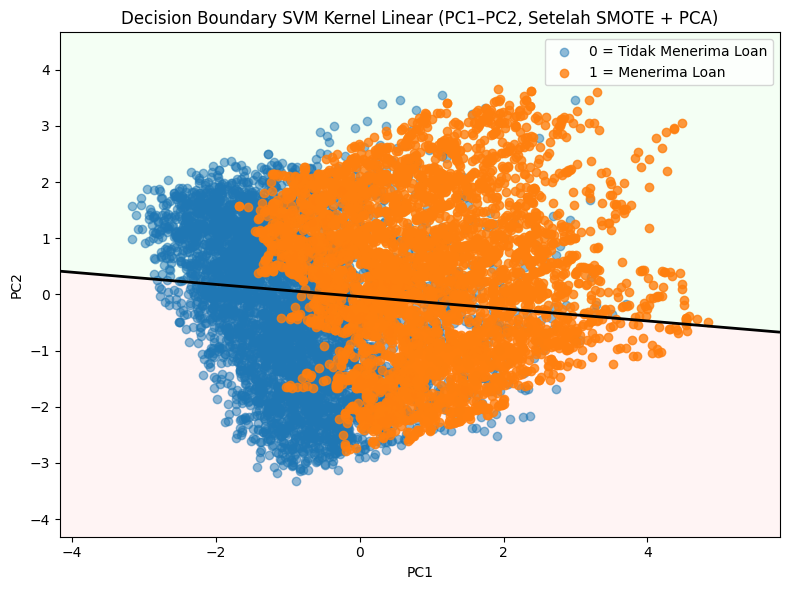

=== SVM KERNEL POLINOM ===
Accuracy : 24.89%
Precision: 25.57%
Recall   : 26.19%
F1-score : 25.87%
Confusion matrix: TP=237, TN=213, FP=690, FN=668



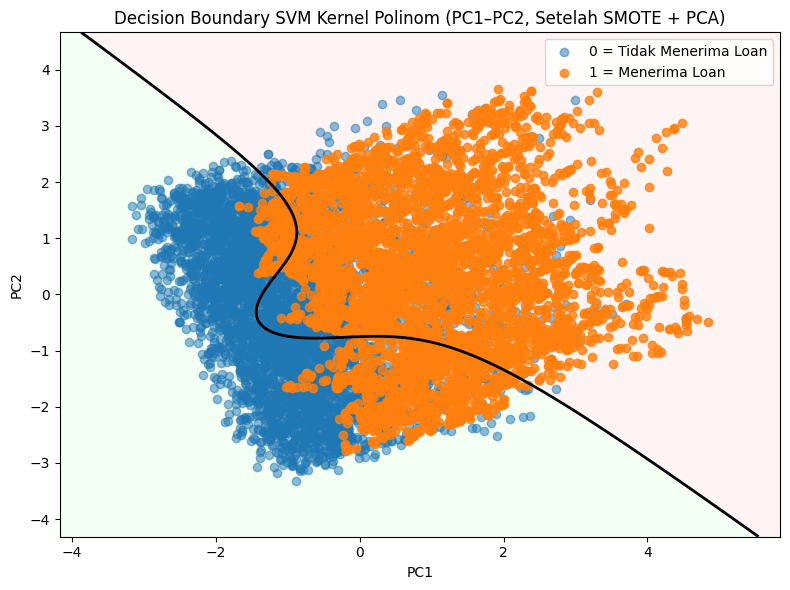

=== SVM KERNEL RBF ===
Accuracy : 84.51%
Precision: 81.79%
Recall   : 88.84%
F1-score : 85.17%
Confusion matrix: TP=804, TN=724, FP=179, FN=101



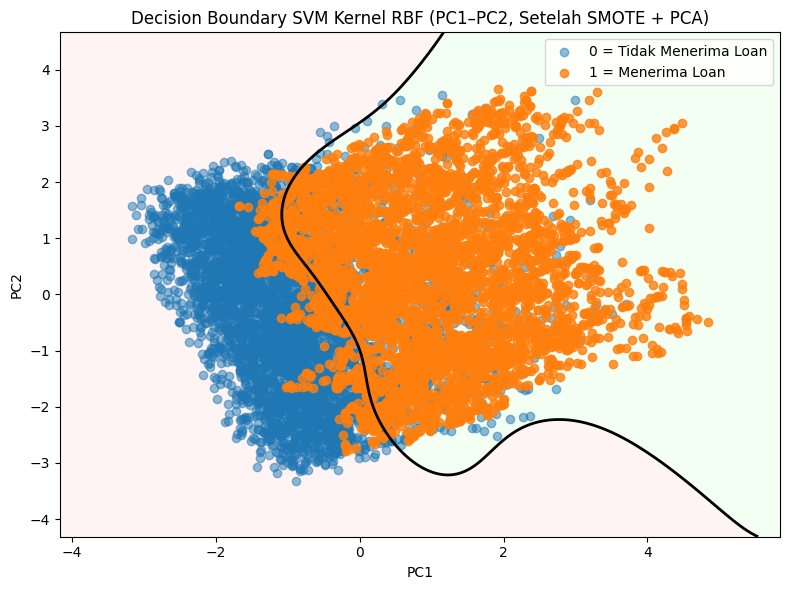

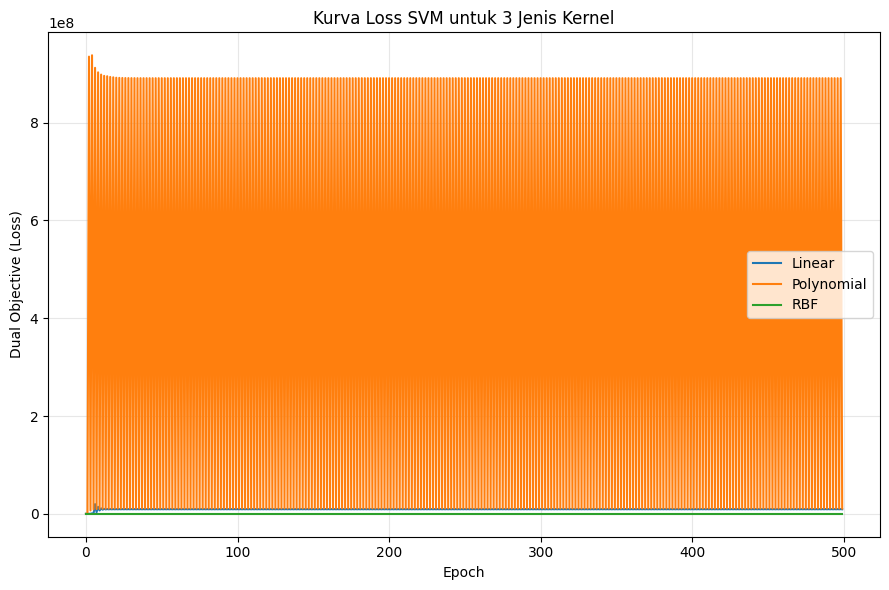

In [3]:
# =====================================================
# 14. Definisi Kelas SVM Kernel (Manual)
# =====================================================
class KernelSVM:
    def __init__(
        self,
        kernel='linear',
        learning_rate=0.001,
        epochs=500,
        C=1.0,
        degree=3,
        gamma=1.0,
        coef0=1.0
    ):
        """
        SVM kernel (manual, pakai formulasi dual).

        Parameter:
        - kernel : 'linear', 'poly', atau 'rbf'
        - learning_rate : lr untuk update alpha
        - epochs : jumlah iterasi training
        - C : parameter regularisasi (0 <= alpha_i <= C)
        - degree : derajat polinom (untuk kernel poly)
        - gamma : parameter skala (poly & rbf)
        - coef0 : bias di dalam kernel poly
        """
        self.kernel = kernel
        self.lr = learning_rate
        self.epochs = epochs
        self.C = C
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0

        self.alphas = None
        self.b = 0.0
        self.X_train = None
        self.y_train = None
        self.losses = []  # simpan nilai objective tiap epoch

    # ---------- FUNGSI KERNEL ----------
    def _kernel(self, X1, X2):
        """
        Hitung matriks kernel antara X1 (n1, d) dan X2 (n2, d).
        """
        X1 = np.atleast_2d(X1)
        X2 = np.atleast_2d(X2)

        if self.kernel == 'linear':
            # K(x,z) = x · z
            return X1 @ X2.T

        elif self.kernel == 'poly':
            # K(x,z) = (gamma * x·z + coef0)^degree
            K = X1 @ X2.T
            K = self.gamma * K + self.coef0
            return np.power(K, self.degree)

        elif self.kernel == 'rbf':
            # K(x,z) = exp(-gamma * ||x - z||^2)
            X1_sq = np.sum(X1 ** 2, axis=1, keepdims=True)          # (n1,1)
            X2_sq = np.sum(X2 ** 2, axis=1, keepdims=True).T        # (1,n2)
            sq_dists = X1_sq + X2_sq - 2 * (X1 @ X2.T)              # (n1,n2)
            return np.exp(-self.gamma * sq_dists)

        else:
            raise ValueError(f"Kernel tidak dikenal: {self.kernel}")

    # ---------- TRAINING (DUAL) ----------
    def fit(self, X, y):
        """
        Latih SVM kernel dengan gradient descent di ruang dual.

        Objective yang diminimalkan:
        L(alpha) = 0.5 * sum_i,j alpha_i alpha_j y_i y_j K_ij - sum_i alpha_i
        dengan 0 <= alpha_i <= C
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        # label {0,1} -> {-1, +1}
        y = np.where(y == 0, -1.0, 1.0)

        n_samples = X.shape[0]
        self.X_train = X
        self.y_train = y

        # matriks kernel K_ij = K(x_i, x_j)
        K = self._kernel(X, X)

        # inisialisasi alpha
        self.alphas = np.zeros(n_samples)
        self.losses = []

        for epoch in range(self.epochs):
            # v = alpha * y
            v = self.alphas * y

            # f_i = sum_j alpha_j y_j K_ij
            f = K @ v

            # grad L wrt alpha_i: g_i = y_i * f_i - 1
            g = y * f - 1.0

            # update alpha
            self.alphas -= self.lr * g

            # project ke [0, C]
            self.alphas = np.clip(self.alphas, 0.0, self.C)

            # hitung objective (buat monitoring)
            v = self.alphas * y
            obj = 0.5 * np.dot(v, K @ v) - np.sum(self.alphas)
            self.losses.append(obj)

        # hitung bias b dari support vector (0 < alpha_i < C)
        v = self.alphas * y
        f = K @ v  # tanpa bias

        sv_mask = (self.alphas > 1e-4) & (self.alphas < self.C - 1e-4)
        if np.any(sv_mask):
            # KKT: y_i (f_i + b) = 1  ->  b = y_i - f_i
            b_vals = y[sv_mask] - f[sv_mask]
        else:
            nz_mask = self.alphas > 1e-4
            if np.any(nz_mask):
                b_vals = y[nz_mask] - f[nz_mask]
            else:
                b_vals = np.array([0.0])

        self.b = float(np.mean(b_vals))
        return self

    # ---------- DECISION FUNCTION ----------
    def decision_function(self, X):
        """
        f(x) = sum_i alpha_i y_i K(x_i, x) + b
        """
        X = np.array(X, dtype=float)
        K_test = self._kernel(X, self.X_train)  # (n_test, n_train)
        v = self.alphas * self.y_train
        return K_test @ v + self.b

    # ---------- PREDIKSI ----------
    def predict(self, X):
        """
        Kembalikan label {0,1} dari sign decision function.
        """
        f = self.decision_function(X)
        return np.where(f >= 0, 1, 0)


# =====================================================
# 15. Fungsi Evaluasi (Accuracy, Precision, Recall, F1)
# =====================================================
def hitung_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    return acc, prec, rec, f1, (tp, tn, fp, fn)


# =====================================================
# 16. Siapkan Data untuk SVM (pakai PCA setelah SMOTE)
# =====================================================
# Gunakan dua komponen utama pertama (PC1, PC2) agar mudah divisualisasikan
X_svm = X_after_pca[:, :2]  # shape: (n_samples, 2)
y_svm = y_res

# Train-test split (80:20)
indices = np.arange(len(X_svm))
np.random.shuffle(indices)

split_idx = int(0.8 * len(X_svm))
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

X_train = X_svm[train_idx]
y_train = y_svm[train_idx]
X_test = X_svm[test_idx]
y_test = y_svm[test_idx]

print("=== Ukuran Data untuk SVM (setelah PCA & SMOTE) ===")
print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0], "\n")


# =====================================================
# 17. Helper: Plot Decision Boundary di Ruang PCA 2D
# =====================================================
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    # background class regions
    plt.contourf(
        xx, yy, Z,
        levels=[-np.inf, 0, np.inf],
        alpha=0.2,
        colors=['#ffcccc', '#ccffcc']
    )

    # decision boundary
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

    # data points
    plt.scatter(
        X[y == 0, 0], X[y == 0, 1],
        alpha=0.5, label='0 = Tidak Menerima Loan'
    )
    plt.scatter(
        X[y == 1, 0], X[y == 1, 1],
        alpha=0.8, label='1 = Menerima Loan'
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =====================================================
# 18. Train & Evaluasi SVM dengan 3 Kernel
# =====================================================

# ---------- 18.1 SVM Kernel Linear ----------
print("=== SVM KERNEL LINEAR ===")
svm_linear = KernelSVM(
    kernel='linear',
    learning_rate=0.001,
    epochs=500,
    C=1.0
)
svm_linear.fit(X_train, y_train)

y_pred_lin = svm_linear.predict(X_test)
acc, prec, rec, f1, (tp, tn, fp, fn) = hitung_metric(y_test, y_pred_lin)

print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print(f"Confusion matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}\n")

plot_decision_boundary(
    svm_linear, X_svm, y_svm,
    "Decision Boundary SVM Kernel Linear (PC1–PC2, Setelah SMOTE + PCA)"
)

# ---------- 18.2 SVM Kernel Polinom ----------
print("=== SVM KERNEL POLINOM ===")
svm_poly = KernelSVM(
    kernel='poly',
    learning_rate=0.001,
    epochs=500,
    C=1.0,
    degree=3,   # bisa dicoba 2, 3, 4, dst.
    gamma=1.0,
    coef0=1.0
)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)
acc, prec, rec, f1, (tp, tn, fp, fn) = hitung_metric(y_test, y_pred_poly)

print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print(f"Confusion matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}\n")

plot_decision_boundary(
    svm_poly, X_svm, y_svm,
    "Decision Boundary SVM Kernel Polinom (PC1–PC2, Setelah SMOTE + PCA)"
)

# ---------- 18.3 SVM Kernel RBF ----------
print("=== SVM KERNEL RBF ===")
svm_rbf = KernelSVM(
    kernel='rbf',
    learning_rate=0.001,
    epochs=500,
    C=1.0,
    gamma=0.5   # bisa di-tuning: 0.1, 0.5, 1.0, dll.
)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
acc, prec, rec, f1, (tp, tn, fp, fn) = hitung_metric(y_test, y_pred_rbf)

print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print(f"Confusion matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}\n")

plot_decision_boundary(
    svm_rbf, X_svm, y_svm,
    "Decision Boundary SVM Kernel RBF (PC1–PC2, Setelah SMOTE + PCA)"
)

# =====================================================
# 19. Plot Kurva Loss untuk 3 Kernel
# =====================================================
plt.figure(figsize=(9, 6))
plt.plot(svm_linear.losses, label='Linear')
plt.plot(svm_poly.losses, label='Polynomial')
plt.plot(svm_rbf.losses, label='RBF')
plt.xlabel("Epoch")
plt.ylabel("Dual Objective (Loss)")
plt.title("Kurva Loss SVM untuk 3 Jenis Kernel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
import pickle

# =====================================================
# 20. Simpan Artifacts Model (Scaler + PCA + SVM RBF)
# =====================================================
artifacts = {
    "feature_cols": feature_cols,   # urutan fitur yang harus dipakai input
    "scaler_after": scaler_after,   # StandardScaler setelah SMOTE (fit di X_res)
    "pca_after": pca_after,         # PCA(n_components=3) setelah SMOTE
    "svm_rbf": svm_rbf              # model SVM kernel RBF terbaik
}

with open("svm_rbf_bank_loan_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("✅ Model & pipeline berhasil disimpan ke 'svm_rbf_bank_loan_model.pkl'")


✅ Model & pipeline berhasil disimpan ke 'svm_rbf_bank_loan_model.pkl'
